**生成式AI的使用 (Generative AI Use)**: 就本次作业而言，生成式AI的使用同样受关于协作的政策约束。与其他合作者一样，每个学生必须独立书写自己的答案（即使参考了交互的输出），并且在提交作业时应包含说明协作性质的附注。使用生成式AI工具实质性地完成作业的大部分内容不符合本次作业的精神，将构成对[荣誉守则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)的违背。

In [1]:
# 将您的 Google Drive 挂载到 Colab 虚拟机。
#from google.colab import drive
#drive.mount('/content/drive')

# TODO：输入您在 Drive 中保存解压后的
# 作业文件夹的名称，例如 'cs231n/assignments/assignment2/'
#FOLDERNAME = 'cs231n/assignments/assignment2/'
#assert FOLDERNAME is not None, "[!] 请输入文件夹名称。"

# 现在我们已经挂载了你的 Drive，这确保了
# Colab 虚拟机的 Python 解释器能够从中加载 python 文件。
#import sys
#sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果你的 Drive 中还没有 CIFAR-10 数据集，
# 以下代码会将其下载到你的 Drive 中。
#%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
#!bash get_datasets.sh
#%cd /content/drive/My\ Drive/$FOLDERNAME

# 卷积网络

到目前为止，我们已经使用了深度全连接网络，并用它们来探索不同的优化策略和网络架构。全连接网络是实验的好平台，因为它们计算效率很高，但在实践中，所有最先进的结果都使用卷积网络取而代之。

首先，你将实现卷积网络中使用的几种层类型。然后，你将使用这些层在 CIFAR-10 数据集上训练一个卷积网络。

In [2]:
# 设置单元格。
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.cnn import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient_array, eval_numerical_gradient
from cs231n.layers import *
from cs231n.fast_layers import *
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置绘图的默认大小
plt.rcParams["font.family"] = "SimHei"  # 强制使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ 返回相对误差 """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [3]:
# 加载（经过预处理的）CIFAR-10 数据。
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


# 卷积：朴素前向传播
卷积网络的核心是卷积操作。在 `cs231n/layers.py` 文件中，在 `conv_forward_naive` 函数里实现卷积层的前向传播。

此时你不需要太担心效率问题；只要用你觉得最清晰的方式编写代码即可。

你可以运行以下代码来测试你的实现：

In [4]:
x_shape = (2, 3, 4, 4)
w_shape = (3, 3, 4, 4)
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)

conv_param = {'stride': 2, 'pad': 1}
out, _ = conv_forward_naive(x, w, b, conv_param)
correct_out = np.array([[[[-0.08759809, -0.10987781],
                           [-0.18387192, -0.2109216 ]],
                          [[ 0.21027089,  0.21661097],
                           [ 0.22847626,  0.23004637]],
                          [[ 0.50813986,  0.54309974],
                           [ 0.64082444,  0.67101435]]],
                         [[[-0.98053589, -1.03143541],
                           [-1.19128892, -1.24695841]],
                          [[ 0.69108355,  0.66880383],
                           [ 0.59480972,  0.56776003]],
                          [[ 2.36270298,  2.36904306],
                           [ 2.38090835,  2.38247847]]]])

# 将你的输出与我们的进行比较；误差应该在 e-8 左右或更小
print('测试 conv_forward_naive')
print('差异 (difference): ', rel_error(out, correct_out))

测试 conv_forward_naive
差异 (difference):  2.2121476417505994e-08


## 旁注：通过卷积进行图像处理

作为一个有趣的方式，既可以检查你的实现，也能更好地理解卷积层能执行的操作类型，我们将使用两张图片作为输入，并手动设置一些执行常见图像处理操作（灰度转换和边缘检测）的滤波器。卷积前向传播会将这些操作应用到每张输入图片上。然后我们可以将结果可视化作为一次健全性检查 (sanity check)。

C:\Users\95265\AppData\Local\Temp\ipykernel_51316\1566538257.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  kitten = imread('cs231n/notebook_images/kitten.jpg')
C:\Users\95265\AppData\Local\Temp\ipykernel_51316\1566538257.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  puppy = imread('cs231n/notebook_images/puppy.jpg')


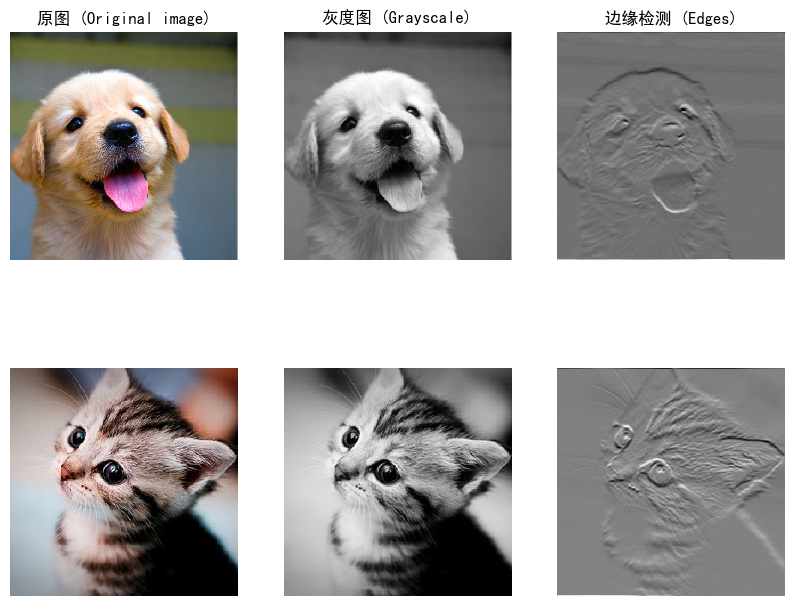

In [5]:
from imageio import imread
from PIL import Image

kitten = imread('cs231n/notebook_images/kitten.jpg')
puppy = imread('cs231n/notebook_images/puppy.jpg')
# kitten is wide, and puppy is already square
d = kitten.shape[1] - kitten.shape[0]
kitten_cropped = kitten[:, d//2:-d//2, :]

img_size = 200   # 如果运行太慢，可以把这个值调小
resized_puppy = np.array(Image.fromarray(puppy).resize((img_size, img_size)))
resized_kitten = np.array(Image.fromarray(kitten_cropped).resize((img_size, img_size)))
x = np.zeros((2, 3, img_size, img_size))
x[0, :, :, :] = resized_puppy.transpose((2, 0, 1))
x[1, :, :, :] = resized_kitten.transpose((2, 0, 1))

# 设置包含2个滤波器的卷积权重，每个都是 3x3 大小
w = np.zeros((2, 3, 3, 3))

# 第一个滤波器将图片转为灰度。
# 设置滤波器的红、绿、蓝通道。
w[0, 0, :, :] = [[0, 0, 0], [0, 0.3, 0], [0, 0, 0]]
w[0, 1, :, :] = [[0, 0, 0], [0, 0.6, 0], [0, 0, 0]]
w[0, 2, :, :] = [[0, 0, 0], [0, 0.1, 0], [0, 0, 0]]

# 第二个滤波器检测蓝色通道的水平边缘。
w[1, 2, :, :] = [[1, 2, 1], [0, 0, 0], [-1, -2, -1]]

# 偏置向量。灰度滤波器不需要任何偏置，
# 但对于边缘检测滤波器，我们希望每个输出加上 128，这样就不会有负数。
b = np.array([0, 128])

# 计算每个输入 x 与每个滤波器 w 的卷积结果，
# 加上偏置 b 进行偏移，并将结果存储在 out 中。
out, _ = conv_forward_naive(x, w, b, {'stride': 1, 'pad': 1})

def imshow_no_ax(img, normalize=True):
    """ 小工具函数，用于以 uint8 格式显示图片并去除坐标轴标签 """
    if normalize:
        img_max, img_min = np.max(img), np.min(img)
        img = 255.0 * (img - img_min) / (img_max - img_min)
    plt.imshow(img.astype('uint8'))
    plt.gca().axis('off')

# 显示原始图片和 conv 操作的结果
plt.subplot(2, 3, 1)
imshow_no_ax(puppy, normalize=False)
plt.title('原图 (Original image)')
plt.subplot(2, 3, 2)
imshow_no_ax(out[0, 0])
plt.title('灰度图 (Grayscale)')
plt.subplot(2, 3, 3)
imshow_no_ax(out[0, 1])
plt.title('边缘检测 (Edges)')
plt.subplot(2, 3, 4)
imshow_no_ax(kitten_cropped, normalize=False)
plt.subplot(2, 3, 5)
imshow_no_ax(out[1, 0])
plt.subplot(2, 3, 6)
imshow_no_ax(out[1, 1])
plt.show()

# 卷积：朴素反向传播
在 `cs231n/layers.py` 文件的 `conv_backward_naive` 函数中实现卷积操作的反向传播。同样，你不需要太担心计算效率的问题。

完成后，运行以下代码用数值梯度检验你的反向传播实现。

_提示：可以参考 https://deeplearning.cs.cmu.edu/F21/document/recitation/Recitation5/CNN_Backprop_Recitation_5_F21.pdf 来获取总体理解。实际的朴素实现涉及使用嵌套的 for 循环，通过来自 dw 和 dout 的独立导数直接计算 dx_padded。_

In [6]:
np.random.seed(231)
x = np.random.randn(4, 3, 5, 5)
w = np.random.randn(2, 3, 3, 3)
b = np.random.randn(2,)
dout = np.random.randn(4, 2, 5, 5)
conv_param = {'stride': 1, 'pad': 1}

dx_num = eval_numerical_gradient_array(lambda x: conv_forward_naive(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_forward_naive(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_forward_naive(x, w, b, conv_param)[0], b, dout)

out, cache = conv_forward_naive(x, w, b, conv_param)
dx, dw, db = conv_backward_naive(dout, cache)

# 你的误差应该在 e-8 左右或更小 (Your errors should be around e-8 or less).
print('测试 conv_backward_naive 函数')
print('dx 误差 (dx error): ', rel_error(dx, dx_num))
print('dw 误差 (dw error): ', rel_error(dw, dw_num))
print('db 误差 (db error): ', rel_error(db, db_num))

测试 conv_backward_naive 函数
dx 误差 (dx error):  1.159803161159293e-08
dw 误差 (dw error):  2.2471264748452487e-10
db 误差 (db error):  3.3726153958780465e-11


# 最大池化：朴素前向传播
在 `cs231n/layers.py` 文件的 `max_pool_forward_naive` 函数中实现最大池化操作的前向传播。同样，你不必太担心计算效率。

运行以下代码来检查你的实现：

In [7]:
x_shape = (2, 3, 4, 4)
x = np.linspace(-0.3, 0.4, num=np.prod(x_shape)).reshape(x_shape)
pool_param = {'pool_width': 2, 'pool_height': 2, 'stride': 2}

out, _ = max_pool_forward_naive(x, pool_param)

correct_out = np.array([[[[-0.26315789, -0.24842105],
                          [-0.20421053, -0.18947368]],
                         [[-0.14526316, -0.13052632],
                          [-0.08631579, -0.07157895]],
                         [[-0.02736842, -0.01263158],
                          [ 0.03157895,  0.04631579]]],
                        [[[ 0.09052632,  0.10526316],
                          [ 0.14947368,  0.16421053]],
                         [[ 0.20842105,  0.22315789],
                          [ 0.26736842,  0.28210526]],
                         [[ 0.32631579,  0.34105263],
                          [ 0.38526316,  0.4       ]]]])

# 将你的输出与我们的进行比较。误差应该在 e-8 量级。
print('Testing max_pool_forward_naive function:')
print('difference: ', rel_error(out, correct_out))

Testing max_pool_forward_naive function:
difference:  4.1666665157267834e-08


# 最大池化：朴素反向传播
在 `cs231n/layers.py` 文件的 `max_pool_backward_naive` 函数中实现最大池化操作的反向传播。你不必担心计算效率。

通过运行以下数值梯度检查代码来检验你的实现：

In [8]:
np.random.seed(231)
x = np.random.randn(3, 2, 8, 8)
dout = np.random.randn(3, 2, 4, 4)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

dx_num = eval_numerical_gradient_array(lambda x: max_pool_forward_naive(x, pool_param)[0], x, dout)

out, cache = max_pool_forward_naive(x, pool_param)
dx = max_pool_backward_naive(dout, cache)

# 你的误差应该在 e-12 量级
print('Testing max_pool_backward_naive function:')
print('dx error: ', rel_error(dx, dx_num))

Testing max_pool_backward_naive function:
dx error:  3.27562514223145e-12


# 快速层 (Fast Layers)

让卷积和池化层变快是一项挑战。为了免去你的痛苦，我们在 `cs231n/fast_layers.py` 文件中提供了卷积和池化层前向与反向传播的快速实现。

### 执行以下单元格，保存此笔记本，并重启运行时
快速卷积的实现依赖于一个 Cython 扩展；要想编译它，请运行以下单元格。接下来，保存 Colab 笔记本（`File > Save`）并且 **重启运行时**（`Runtime > Restart runtime`）。然后你可以从上到下重新执行之前的单元格，并跳过下面这个单元格，因为它只为了编译而需要运行一次。

In [9]:
# 运行此单元格后记得重启运行时！
#%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/
#!python setup.py build_ext --inplace
#%cd /content/drive/My\ Drive/$FOLDERNAME/

快速版卷积和池化层的 API 与你在上面实现的朴素版完全相同：前向传播接收数据、权重和参数，并产生输出和缓存对象；反向传播接收上游导数和缓存对象，并产生关于数据和权重的梯度。

**注意：** 只有当池化区域互不重叠且能平铺输入时，池化的快速实现才会发挥最佳性能。如果这些条件不满足，那么快速池化的实现不会比朴素实现快多少。

你可以通过运行以下代码来比较这些层的朴素版本和快速版本的性能：

In [10]:
# 相对误差应该在 e-9 或更小量级。
from cs231n.fast_layers import conv_forward_fast, conv_backward_fast
from time import time
np.random.seed(231)
x = np.random.randn(100, 3, 31, 31)
w = np.random.randn(25, 3, 3, 3)
b = np.random.randn(25,)
dout = np.random.randn(100, 25, 16, 16)
conv_param = {'stride': 2, 'pad': 1}

t0 = time()
out_naive, cache_naive = conv_forward_naive(x, w, b, conv_param)
t1 = time()
out_fast, cache_fast = conv_forward_fast(x, w, b, conv_param)
t2 = time()

print('Testing conv_forward_fast:')
print('Naive: %fs' % (t1 - t0))
print('Fast: %fs' % (t2 - t1))
print('Speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('Difference: ', rel_error(out_naive, out_fast))

t0 = time()
dx_naive, dw_naive, db_naive = conv_backward_naive(dout, cache_naive)
t1 = time()
dx_fast, dw_fast, db_fast = conv_backward_fast(dout, cache_fast)
t2 = time()

print('\nTesting conv_backward_fast:')
print('Naive: %fs' % (t1 - t0))
print('Fast: %fs' % (t2 - t1))
print('Speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('dx difference: ', rel_error(dx_naive, dx_fast))
print('dw difference: ', rel_error(dw_naive, dw_fast))
print('db difference: ', rel_error(db_naive, db_fast))

Testing conv_forward_fast:
Naive: 2.123961s
Fast: 0.006417s
Speedup: 330.987925x
Difference:  4.926407851494105e-11

Testing conv_backward_fast:
Naive: 2.725220s
Fast: 0.006447s
Speedup: 422.721893x
dx difference:  1.949764775345631e-11
dw difference:  4.957046344783224e-13
db difference:  4.102931673316555e-15


In [11]:
# 相对误差应该接近 0.0。
from cs231n.fast_layers import max_pool_forward_fast, max_pool_backward_fast
np.random.seed(231)
x = np.random.randn(100, 3, 32, 32)
dout = np.random.randn(100, 3, 16, 16)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

t0 = time()
out_naive, cache_naive = max_pool_forward_naive(x, pool_param)
t1 = time()
out_fast, cache_fast = max_pool_forward_fast(x, pool_param)
t2 = time()

print('Testing pool_forward_fast:')
print('Naive: %fs' % (t1 - t0))
print('fast: %fs' % (t2 - t1))
print('speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('difference: ', rel_error(out_naive, out_fast))

t0 = time()
dx_naive = max_pool_backward_naive(dout, cache_naive)
t1 = time()
dx_fast = max_pool_backward_fast(dout, cache_fast)
t2 = time()

print('\nTesting pool_backward_fast:')
print('Naive: %fs' % (t1 - t0))
print('fast: %fs' % (t2 - t1))
print('speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('dx difference: ', rel_error(dx_naive, dx_fast))

Testing pool_forward_fast:
Naive: 0.159800s
fast: 0.002180s
speedup: 73.315467x
difference:  0.0

Testing pool_backward_fast:
Naive: 0.423968s
fast: 0.006819s
speedup: 62.174469x
dx difference:  0.0


# 卷积“三明治”层
在之前的作业中，我们引入了“三明治”层的概念，它将多项操作组合成常用的模式。在 `cs231n/layer_utils.py` 文件中，你可以找到一些实现了卷积网络中常用模式的三明治层。运行以下单元格来对其进行可用性/正确性检查（sanity check）。

In [12]:
from cs231n.layer_utils import conv_relu_pool_forward, conv_relu_pool_backward
np.random.seed(231)
x = np.random.randn(2, 3, 16, 16)
w = np.random.randn(3, 3, 3, 3)
b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

out, cache = conv_relu_pool_forward(x, w, b, conv_param, pool_param)
dx, dw, db = conv_relu_pool_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], b, dout)

# 相对误差应该在 e-8 左右或更小
print('Testing conv_relu_pool')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing conv_relu_pool
dx error:  9.591132621921372e-09
dw error:  5.802401370096438e-09
db error:  1.0146343411762047e-09


In [13]:
from cs231n.layer_utils import conv_relu_forward, conv_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 8, 8)
w = np.random.randn(3, 3, 3, 3)
b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}

out, cache = conv_relu_forward(x, w, b, conv_param)
dx, dw, db = conv_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_forward(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_forward(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_forward(x, w, b, conv_param)[0], b, dout)

# 相对误差应该在 e-8 左右或更小
print('Testing conv_relu:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing conv_relu:
dx error:  1.5218619980349303e-09
dw error:  2.702022646099404e-10
db error:  1.451272393591721e-10


# 三层卷积网络
既然你已经实现了所有必要的层，我们可以将它们组合成一个简单的卷积网络了。

打开 `cs231n/classifiers/cnn.py` 文件并完成 `ThreeLayerConvNet` 类的实现。记住，你可以在你的实现中使用快速/三明治层（已经为你导入）。运行以下单元格来帮助调试：

## 健全性检查：损失 (健全性检查：损失 (Sanity Check Loss))
在构建新网络后，你应该做的第一件事就是对损失进行健全性检查。当我们使用 softmax 损失且权重随机（没有正则化）时，我们预计对于 `C` 个类别的损失大约为 `log(C)`。当我们加入正则化时，损失应该会略微上升。

In [14]:
model = ThreeLayerConvNet()

N = 50
X = np.random.randn(N, 3, 32, 32)
y = np.random.randint(10, size=N)

loss, grads = model.loss(X, y)
print('Initial loss (no regularization): ', loss)

model.reg = 0.5
loss, grads = model.loss(X, y)
print('Initial loss (with regularization): ', loss)

Initial loss (no regularization):  2.302586071243987
Initial loss (with regularization):  2.5082556233317708


## 梯度检查
在损失看起来合理之后，使用数值梯度检查来确保你的反向传播是正确的。当你使用数值梯度检查时，你应该使用少量的人造数据和每一层少量的神经元。注意：即使是正确的实现，仍然可能产生达到 e-2 量级的相对误差。

In [15]:
num_inputs = 2
input_dim = (3, 16, 16)
reg = 0.0
num_classes = 10
np.random.seed(231)
X = np.random.randn(num_inputs, *input_dim)
y = np.random.randint(num_classes, size=num_inputs)

model = ThreeLayerConvNet(
    num_filters=3,
    filter_size=3,
    input_dim=input_dim,
    hidden_dim=7,
    dtype=np.float64
)
loss, grads = model.loss(X, y)
# 误差应该很小，但正确的实现可能仍然具有
# 达到 e-2 量级的相对误差
for param_name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    param_grad_num = eval_numerical_gradient(f, model.params[param_name], verbose=False, h=1e-6)
    e = rel_error(param_grad_num, grads[param_name])
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W1 max relative error: 3.053965e-04
W2 max relative error: 1.822723e-02
W3 max relative error: 3.422399e-04
b1 max relative error: 3.397321e-06
b2 max relative error: 2.517459e-03
b3 max relative error: 9.711800e-10


## 在小数据集上过拟合
一个好用的小技巧是用仅仅几个训练样本来训练你的模型。你应该能够在小数据集上过拟合，这会导致非常高的训练准确率和相对较低的验证准确率。

In [16]:
np.random.seed(231)

num_train = 100
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

model = ThreeLayerConvNet(weight_scale=1e-2)

solver = Solver(
    model,
    small_data,
    num_epochs=15,
    batch_size=50,
    update_rule='adam',
    optim_config={'learning_rate': 1e-3,},
    verbose=True,
    print_every=1
)
solver.train()

(Iteration 1 / 30) loss: 2.414060
(Epoch 0 / 15) train acc: 0.200000; val_acc: 0.137000
(Iteration 2 / 30) loss: 3.102925
(Epoch 1 / 15) train acc: 0.140000; val_acc: 0.087000
(Iteration 3 / 30) loss: 2.270330
(Iteration 4 / 30) loss: 2.096705
(Epoch 2 / 15) train acc: 0.240000; val_acc: 0.094000
(Iteration 5 / 30) loss: 1.838880
(Iteration 6 / 30) loss: 1.934188
(Epoch 3 / 15) train acc: 0.510000; val_acc: 0.173000
(Iteration 7 / 30) loss: 1.827912
(Iteration 8 / 30) loss: 1.639574
(Epoch 4 / 15) train acc: 0.520000; val_acc: 0.188000
(Iteration 9 / 30) loss: 1.330082
(Iteration 10 / 30) loss: 1.756115
(Epoch 5 / 15) train acc: 0.630000; val_acc: 0.167000
(Iteration 11 / 30) loss: 1.024162
(Iteration 12 / 30) loss: 1.041826
(Epoch 6 / 15) train acc: 0.750000; val_acc: 0.229000
(Iteration 13 / 30) loss: 1.142777
(Iteration 14 / 30) loss: 0.835706
(Epoch 7 / 15) train acc: 0.790000; val_acc: 0.247000
(Iteration 15 / 30) loss: 0.587786
(Iteration 16 / 30) loss: 0.645509
(Epoch 8 / 15) tr

In [17]:
# 打印最终的训练准确率。
print(
    "Small data training accuracy:",
    solver.check_accuracy(small_data['X_train'], small_data['y_train'])
)

Small data training accuracy: 0.82


In [18]:
# 打印最终的验证准确率。
print(
    "Small data validation accuracy:",
    solver.check_accuracy(small_data['X_val'], small_data['y_val'])
)

Small data validation accuracy: 0.252


绘制出的损失、训练准确率和验证准确率曲线应当表现出明显的过拟合：

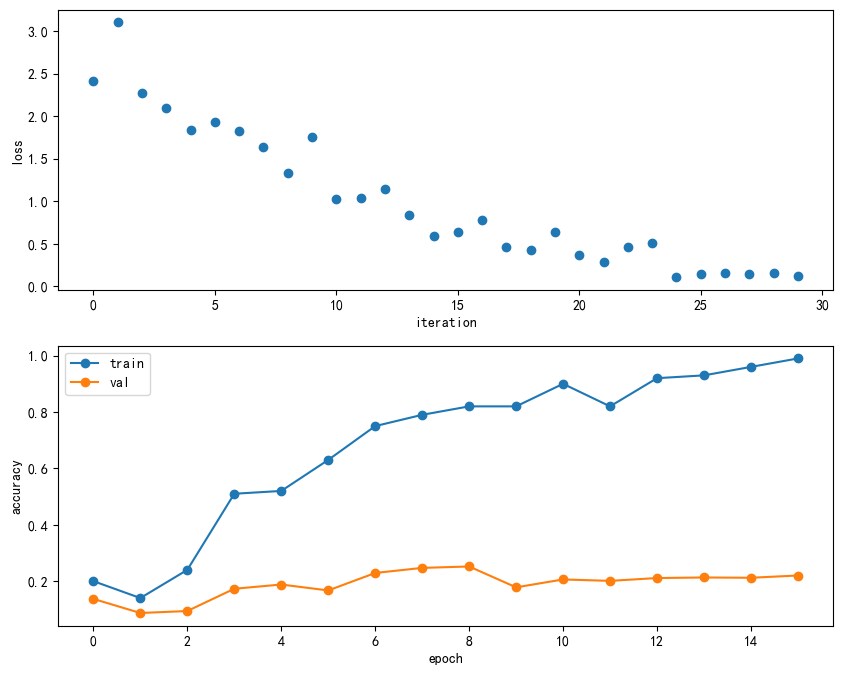

In [19]:
plt.subplot(2, 1, 1)
plt.plot(solver.loss_history, 'o')
plt.xlabel('iteration')
plt.ylabel('loss')

plt.subplot(2, 1, 2)
plt.plot(solver.train_acc_history, '-o')
plt.plot(solver.val_acc_history, '-o')
plt.legend(['train', 'val'], loc='upper left')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

## 训练网络
通过将这三层卷积网络训练一个周期（epoch），你应该可以在训练集上达到超过 40% 的准确率：

In [20]:
model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)

solver = Solver(
    model,
    data,
    num_epochs=1,
    batch_size=50,
    update_rule='adam',
    optim_config={'learning_rate': 1e-3,},
    verbose=True,
    print_every=20
)
solver.train()

(Iteration 1 / 980) loss: 2.304740
(Epoch 0 / 1) train acc: 0.103000; val_acc: 0.107000
(Iteration 21 / 980) loss: 2.098229
(Iteration 41 / 980) loss: 1.949788
(Iteration 61 / 980) loss: 1.888398
(Iteration 81 / 980) loss: 1.877093
(Iteration 101 / 980) loss: 1.851877
(Iteration 121 / 980) loss: 1.859353
(Iteration 141 / 980) loss: 1.800181
(Iteration 161 / 980) loss: 2.143292
(Iteration 181 / 980) loss: 1.830573
(Iteration 201 / 980) loss: 2.037280
(Iteration 221 / 980) loss: 2.020304
(Iteration 241 / 980) loss: 1.823728
(Iteration 261 / 980) loss: 1.692679
(Iteration 281 / 980) loss: 1.882594
(Iteration 301 / 980) loss: 1.798261
(Iteration 321 / 980) loss: 1.851960
(Iteration 341 / 980) loss: 1.716323
(Iteration 361 / 980) loss: 1.897655
(Iteration 381 / 980) loss: 1.319744
(Iteration 401 / 980) loss: 1.738790
(Iteration 421 / 980) loss: 1.488866
(Iteration 441 / 980) loss: 1.718409
(Iteration 461 / 980) loss: 1.744440
(Iteration 481 / 980) loss: 1.605460
(Iteration 501 / 980) loss: 

In [21]:
# 打印最终的训练准确率。
print(
    "Full data training accuracy:",
    solver.check_accuracy(data['X_train'], data['y_train'])
)

Full data training accuracy: 0.4761836734693878


In [22]:
# 打印最终的验证准确率。
print(
    "Full data validation accuracy:",
    solver.check_accuracy(data['X_val'], data['y_val'])
)

Full data validation accuracy: 0.499


## 可视化滤波器
你可以通过运行以下代码来可视化训练后网络第一层卷积的滤波器：

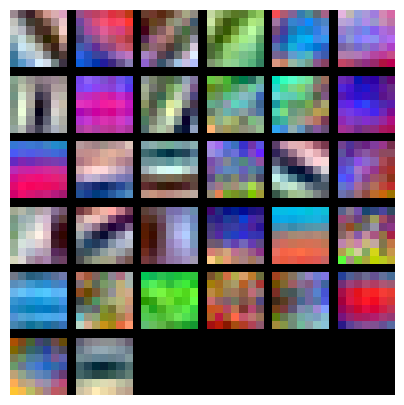

In [23]:
from cs231n.vis_utils import visualize_grid

grid = visualize_grid(model.params['W1'].transpose(0, 2, 3, 1))
plt.imshow(grid.astype('uint8'))
plt.axis('off')
plt.gcf().set_size_inches(5, 5)
plt.show()

# 空间批量归一化 (Spatial Batch Normalization)
我们在训练深度全连接网络时已经看到，批量归一化是一项非常有用的技术。正如原论文（链接在 `BatchNormalization.ipynb` 中）所提出的，批量归一化也可以用于卷积网络，但我们需要对其进行一点微调；修改后的方法将被称为“空间批量归一化”（spatial batch normalization）。

正常情况下，批量归一化接收形状为 `(N, D)` 的输入并产生形状为 `(N, D)` 的输出，其中我们在 minibatch 的维度 `N` 上进行归一化。对于来自卷积层的数据，批量归一化需要接受形状为 `(N, C, H, W)` 的输入，并产生形状为 `(N, C, H, W)` 的输出，其中 `N` 维代表 minibatch 的大小，而 `(H, W)` 维度代表特征图的空间尺寸。

如果特征图是通过卷积产生的，我们期望每个特征通道的统计数据（例如均值、方差）在不同图片之间以及同一图片的不同位置上相对一致——毕竟，每一个特征通道都是由相同的卷积滤波器产生的！因此，空间批量归一化通过在 minibatch 维度 `N` 以及空间维度 `H` 和 `W` 上计算统计量，来为 `C` 个特征通道的每一个分别计算均值和方差。


[1] [Sergey Ioffe and Christian Szegedy, "Batch Normalization: Accelerating Deep Network Training by Reducing
Internal Covariate Shift", ICML 2015.](https://arxiv.org/abs/1502.03167)

# 空间批量归一化：前向传播

在 `cs231n/layers.py` 文件中的 `spatial_batchnorm_forward` 函数中实现空间批量归一化的前向传播。运行以下代码来检查你的实现：

In [25]:
np.random.seed(231)

# 通过检查均值和方差，检验训练时的前向传播
# 测试在空间批量归一化前后特征的均值和方差。
N, C, H, W = 2, 3, 4, 5
x = 4 * np.random.randn(N, C, H, W) + 10

print('Before spatial batch normalization:')
print('  shape: ', x.shape)
print('  means: ', x.mean(axis=(0, 2, 3)))
print('  stds: ', x.std(axis=(0, 2, 3)))

# Means should be close to zero and stds close to one
gamma, beta = np.ones(C), np.zeros(C)
bn_param = {'mode': 'train'}
out, _ = spatial_batchnorm_forward(x, gamma, beta, bn_param)
print('After spatial batch normalization:')
print('  shape: ', out.shape)
print('  means: ', out.mean(axis=(0, 2, 3)))
print('  stds: ', out.std(axis=(0, 2, 3)))

# Means should be close to beta and stds close to gamma
gamma, beta = np.asarray([3, 4, 5]), np.asarray([6, 7, 8])
out, _ = spatial_batchnorm_forward(x, gamma, beta, bn_param)
print('After spatial batch normalization (nontrivial gamma, beta):')
print('  shape: ', out.shape)
print('  means: ', out.mean(axis=(0, 2, 3)))
print('  stds: ', out.std(axis=(0, 2, 3)))

Before spatial batch normalization:
  shape:  (2, 3, 4, 5)
  means:  [9.33463814 8.90909116 9.11056338]
  stds:  [3.61447857 3.19347686 3.5168142 ]
After spatial batch normalization:
  shape:  (2, 3, 4, 5)
  means:  [ 6.18949336e-16  5.99520433e-16 -1.22124533e-16]
  stds:  [0.99999962 0.99999951 0.9999996 ]
After spatial batch normalization (nontrivial gamma, beta):
  shape:  (2, 3, 4, 5)
  means:  [6. 7. 8.]
  stds:  [2.99999885 3.99999804 4.99999798]


In [26]:
np.random.seed(231)

# 通过运行训练时的前向传播，进而检验测试时的前向传播
# 多次运行以预热（warm up）滑动平均值，然后
# 检验在测试时前向传播后激活值的均值和方差
# 是否符合预期。
N, C, H, W = 10, 4, 11, 12

bn_param = {'mode': 'train'}
gamma = np.ones(C)
beta = np.zeros(C)
for t in range(50):
  x = 2.3 * np.random.randn(N, C, H, W) + 13
  spatial_batchnorm_forward(x, gamma, beta, bn_param)
bn_param['mode'] = 'test'
x = 2.3 * np.random.randn(N, C, H, W) + 13
a_norm, _ = spatial_batchnorm_forward(x, gamma, beta, bn_param)

# Means should be close to zero and stds close to one, but will be
# noisier than training-time forward passes.
print('After spatial batch normalization (test-time):')
print('  means: ', a_norm.mean(axis=(0, 2, 3)))
print('  stds: ', a_norm.std(axis=(0, 2, 3)))

After spatial batch normalization (test-time):
  means:  [-0.08034406  0.07562881  0.05716371  0.04378383]
  stds:  [0.96718744 1.0299714  1.02887624 1.00585577]


# 空间批量归一化：反向传播
在 `cs231n/layers.py` 文件中的 `spatial_batchnorm_backward` 函数中实现空间批量归一化的反向传播。运行以下代码使用数值梯度检查来检验你的实现：

In [27]:
np.random.seed(231)
N, C, H, W = 2, 3, 4, 5
x = 5 * np.random.randn(N, C, H, W) + 12
gamma = np.random.randn(C)
beta = np.random.randn(C)
dout = np.random.randn(N, C, H, W)

bn_param = {'mode': 'train'}
fx = lambda x: spatial_batchnorm_forward(x, gamma, beta, bn_param)[0]
fg = lambda a: spatial_batchnorm_forward(x, gamma, beta, bn_param)[0]
fb = lambda b: spatial_batchnorm_forward(x, gamma, beta, bn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma, dout)
db_num = eval_numerical_gradient_array(fb, beta, dout)

#You should expect errors of magnitudes between 1e-12~1e-06
_, cache = spatial_batchnorm_forward(x, gamma, beta, bn_param)
dx, dgamma, dbeta = spatial_batchnorm_backward(dout, cache)
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))

dx error:  2.786648197756335e-07
dgamma error:  7.0974817113608705e-12
dbeta error:  3.275608725278405e-12


# 空间组归一化 (Spatial Group Normalization)
在之前的笔记本中，我们提到层归一化是一项替代归一化技术，它缓解了批量归一化针对批大小（batch size）的限制。然而，正如 [2] 的作者观察到的，在卷积层中使用层归一化时表现不如批量归一化：

>在全连接网络中，层里的所有隐藏单元大多会被期望对最终预测有类似的贡献，对该层进行输入的重新置中（re-centering）和重新缩放（rescaling）效果会很好。但是针对卷积神经网络，这类相似预测的假设却不再成立。大量的有着靠近图片边界感受野的隐藏单元很难被激活，因此具有与层中其它隐藏单元截然不同的统计规律。

[3] 的作者提出了一种过渡技术。与层归一化（对单个数据点的全部特征进行归一化）不同，他们建议将每个数据点的特征一致地划分为 G 个组，然后采用 “每个组、每个数据点（per-group per-datapoint）” 的方式进行归一化。

<p align="center">
<img src="https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/a2/normalization.png">
</p>
<center>目前讨论的归一化技术的直观对比（图片修改自 [3]）</center>

尽管平等贡献依然作为每个组里的基本假设而存在，作者假设这并没有多大的问题，因为为了视觉识别，特征内天生会产生这种分组（innate grouping）。他们用来加以说明的一个示例是，在传统计算机视觉中，很多高性能手工特征都会显式地组合这些术语。以定向梯度直方图 (HOG)[4] 为例——在每个空间上的局部块内计算完成直方图之后，每一个块上的直方图都会先进行归一化，再会被拼接在一起形成最终特征向量。

现在你来实现组归一化。

[2] [Ba, Jimmy Lei, Jamie Ryan Kiros, and Geoffrey E. Hinton. "Layer Normalization." stat 1050 (2016): 21.](https://arxiv.org/pdf/1607.06450.pdf)


[3] [Wu, Yuxin, and Kaiming He. "Group Normalization." arXiv preprint arXiv:1803.08494 (2018).](https://arxiv.org/abs/1803.08494)


[4] [N. Dalal and B. Triggs. Histograms of oriented gradients for
human detection. In Computer Vision and Pattern Recognition
(CVPR), 2005.](https://ieeexplore.ieee.org/abstract/document/1467360/)

# 空间组归一化：前向传播

在 `cs231n/layers.py` 文件的 `spatial_groupnorm_forward` 函数中实现组归一化的前向传播。通过运行以下代码来检验你的实现：

In [28]:
np.random.seed(231)

# 通过检查均值和方差，检验训练时的前向传播
# 测试在空间批量归一化前后特征的均值和方差。
N, C, H, W = 2, 6, 4, 5
G = 2
x = 4 * np.random.randn(N, C, H, W) + 10
x_g = x.reshape((N*G,-1))
print('Before spatial group normalization:')
print('  shape: ', x.shape)
print('  means: ', x_g.mean(axis=1))
print('  stds: ', x_g.std(axis=1))

# Means should be close to zero and stds close to one
gamma, beta = np.ones((1,C,1,1)), np.zeros((1,C,1,1))
bn_param = {'mode': 'train'}

out, _ = spatial_groupnorm_forward(x, gamma, beta, G, bn_param)
out_g = out.reshape((N*G,-1))
print('After spatial group normalization:')
print('  shape: ', out.shape)
print('  means: ', out_g.mean(axis=1))
print('  stds: ', out_g.std(axis=1))

Before spatial group normalization:
  shape:  (2, 6, 4, 5)
  means:  [9.72505327 8.51114185 8.9147544  9.43448077]
  stds:  [3.67070958 3.09892597 4.27043622 3.97521327]
After spatial group normalization:
  shape:  (2, 6, 4, 5)
  means:  [-2.14643118e-16  5.25505565e-16  2.65528340e-16 -3.38618023e-16]
  stds:  [0.99999963 0.99999948 0.99999973 0.99999968]


# 空间组归一化：反向传播
在 `cs231n/layers.py` 文件的 `spatial_groupnorm_backward` 函数中实现空间组归一化的反向传播。运行以下代码，借由数值梯度检验来检查你的实现：

In [29]:
np.random.seed(231)
N, C, H, W = 2, 6, 4, 5
G = 2
x = 5 * np.random.randn(N, C, H, W) + 12
gamma = np.random.randn(1,C,1,1)
beta = np.random.randn(1,C,1,1)
dout = np.random.randn(N, C, H, W)

gn_param = {}
fx = lambda x: spatial_groupnorm_forward(x, gamma, beta, G, gn_param)[0]
fg = lambda a: spatial_groupnorm_forward(x, gamma, beta, G, gn_param)[0]
fb = lambda b: spatial_groupnorm_forward(x, gamma, beta, G, gn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma, dout)
db_num = eval_numerical_gradient_array(fb, beta, dout)

_, cache = spatial_groupnorm_forward(x, gamma, beta, G, gn_param)
dx, dgamma, dbeta = spatial_groupnorm_backward(dout, cache)

# You should expect errors of magnitudes between 1e-12 and 1e-07.
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))

dx error:  7.413109404620405e-08
dgamma error:  9.468195772749234e-12
dbeta error:  3.354494437653335e-12
